# Save the data in the right format

In [1]:
import numpy as np
import h5py
from scipy import ndimage
import os
import matplotlib.pyplot as plt
import random

import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from dataset import SuperResolutionDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import time

import torchmetrics
from skimage.metrics import structural_similarity as ssim


import wandb



# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [ ]:
# Load Training Dataset (for checking shape)
train_dataset = SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

# Load Test Dataset (for evaluation)
test_dataset = SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Get a batch for inference (only LR images)
lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)


In [ ]:
# Define dataset paths
lr_hdf5_path = "../data/Nisp_train_cosmos.hdf5"
hr_hdf5_path = "../data/Nircam_train_cosmos.hdf5"

# Load Training Dataset (set split="train" explicitly)
train_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch a batch from the training dataset
lr_batch, hr_batch = next(iter(train_loader))

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.squeeze().cpu().numpy()  
hr_batch_np = hr_batch.squeeze().cpu().numpy()  

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()


# Diffusion based model

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# === Timestep Embedding ===
def get_timestep_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    exponent = -torch.arange(half_dim, dtype=torch.float32, device=timesteps.device) * (math.log(10000.0) / (half_dim - 1))
    emb = timesteps.float().unsqueeze(1) * torch.exp(exponent.unsqueeze(0))
    return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

# === UNet with Condition + Time Embedding ===
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64, activation_fn=nn.ReLU, time_embed_dim=128):
        super().__init__()
        self.activation_fn = activation_fn
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.hidden_dim = hidden_dim

        # Encoder
        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=4, stride=2, padding=1),  # 66 → 33
            activation_fn()
        )
        self.encoder2 = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=4, stride=2, padding=1),  # 33 → 16
            activation_fn()
        )
        self.encoder3 = nn.Sequential(
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, kernel_size=4, stride=2, padding=1),  # 16 → 8
            activation_fn()
        )

        # Conditioning and time
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, hidden_dim * 4),
            activation_fn()
        )
        self.cross_attention = nn.Conv2d(hidden_dim * 4 * 2, hidden_dim * 4, kernel_size=1)

        # Decoder using Upsample + Conv2d (checkerboard-free)
        self.decoder1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(hidden_dim * 4, hidden_dim * 2, kernel_size=3, padding=1),
            activation_fn()
        )
        self.decoder2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(hidden_dim * 2, hidden_dim, kernel_size=3, padding=1),
            activation_fn()
        )
        self.decoder3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(hidden_dim, hidden_dim // 2, kernel_size=3, padding=1),
            activation_fn()
        )

        # Final output layer
        self.output_conv = nn.Conv2d(hidden_dim // 2, out_channels, kernel_size=3, padding=1)

    def forward(self, x, condition, t_embed):
        x1 = self.encoder1(x)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)

        condition = self.condition_proj(condition)
        condition = F.interpolate(condition, size=(x3.shape[2], x3.shape[3]), mode="bilinear", align_corners=True)

        t_proj = self.time_mlp(t_embed).view(x3.shape[0], -1, 1, 1).expand(-1, -1, x3.shape[2], x3.shape[3])
        x3 = torch.cat([x3 + t_proj, condition], dim=1)
        x3 = self.cross_attention(x3)

        x = self.decoder1(x3)
        x = self.align_dims(x, x2)
        x = x + x2

        x = self.decoder2(x)
        x = self.align_dims(x, x1)
        x = x + x1

        x = self.decoder3(x)
        x = self.output_conv(x)

        # Pad to exactly 66×66
        x = self.align_dims(x, target=torch.empty(x.size(0), x.size(1), 66, 66, device=x.device))
        return x

    def align_dims(self, x, target):
        if isinstance(target, torch.Tensor):
            target_h, target_w = target.size(2), target.size(3)
        else:
            target_h, target_w = target[0], target[1]
        diffY = target_h - x.size(2)
        diffX = target_w - x.size(3)
        if diffX != 0 or diffY != 0:
            x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        return x

# === Upsampler Module ===
class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, upscale_factor=2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels * (upscale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.relu(self.pixel_shuffle(self.conv1(x)))
        x = self.conv2(x)
        return x

# === Diffusion Wrapper with Time Embedding ===
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=500, time_embed_dim=128):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps
        self.time_embed_dim = time_embed_dim

    def forward(self, x, t, condition):
        t_embed = get_timestep_embedding(t, self.time_embed_dim)
        return self.unet(x, condition, t_embed)

# === Main Super-Resolution Diffusion Model ===
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        upscaled = self.upsampler(x)
        noise = torch.randn_like(upscaled, device=upscaled.device)
        alpha_t = cosine_schedule(t, self.diffusion.timesteps).view(-1, 1, 1, 1)
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise
        output = self.diffusion(noisy_image, t, upscaled)
        return F.interpolate(output, size=(66, 66), mode="bilinear", align_corners=True)

# === Cosine Noise Schedule ===
def cosine_schedule(t, total_timesteps=500):
    return torch.cos((t / total_timesteps) * (0.5 * torch.pi))

# Instantiate models and move them to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Example input on GPU
x = torch.randn(1, 1, 40, 40, device=device) 
t = torch.tensor([500], device=device) 

# Run the model
output = model(x, t)

print("Output shape:", output.shape)  

Output shape: torch.Size([1, 1, 66, 66])


# Train

In [ ]:
# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 200

# Train-Test Dataloaders
train_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="train", sample_fraction=0.5),
    batch_size=64, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True
)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...") 

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):

        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)
        
        output = model(lr_batch, t)# Forward pass
        loss = criterion(output, hr_batch)# Compute loss
        epoch_loss += loss.item()
        
        optimizer.zero_grad()# Backpropagation
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")


In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model has {count_parameters(model) / 1e6:.2f} million trainable parameters")


Model has 1.21 million trainable parameters


In [4]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0))


Quadro RTX 6000
_CudaDeviceProperties(name='Quadro RTX 6000', major=7, minor=5, total_memory=22504MB, multi_processor_count=72, uuid=c21bbb54-caac-6137-9d43-7fff80369434, L2_cache_size=6MB)


In [5]:
x = torch.randn(1, 1, 44, 44).cuda()  # low-res input
t = torch.tensor([250]).cuda()       # example timestep
start_time = time.time()

with torch.no_grad():
    _ = model(x, t)

elapsed = time.time() - start_time
print(f"Inference time for one image (single step): {elapsed:.4f} seconds")


Inference time for one image (single step): 0.0095 seconds


# Evaluate 

/tmp/ipykernel_1261638/150345597.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


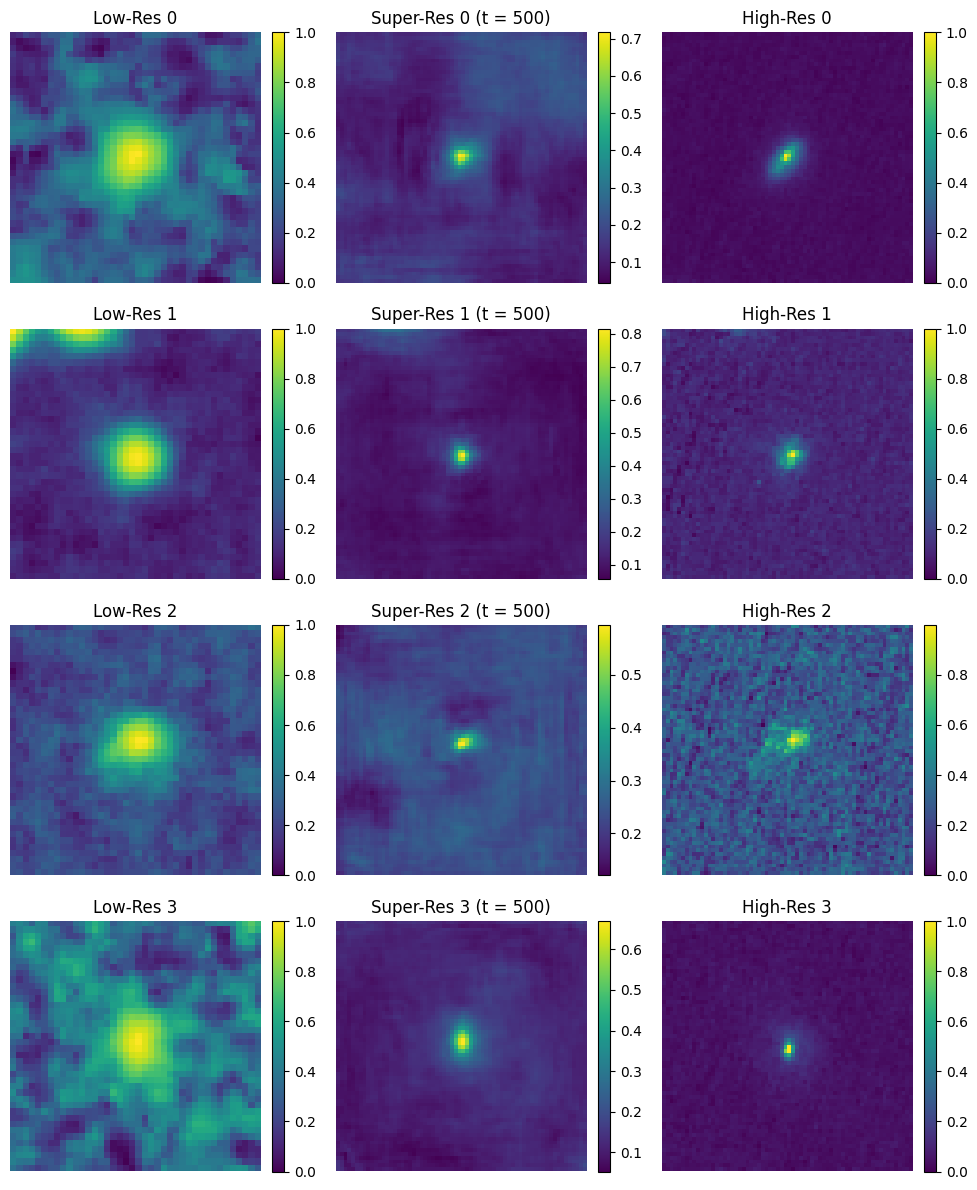

In [8]:
# Load model
checkpoint_path = "super_resolution_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define DataLoader with num_workers for speed

test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="test", sample_fraction=1),
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


# === Pick a random test batch ===
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# === Inference with timestep t (adjustable) ===
t_value = 500 # You can try 0, 50, 100, 250, etc.
t_test = torch.full((lr_batch.shape[0],), t_value, dtype=torch.long, device=device)

with torch.no_grad(), torch.cuda.amp.autocast():
    sr_batch = model(lr_batch, t_test).cpu()

# === Convert to numpy for visualization ===
lr_batch_np = lr_batch.cpu().squeeze().numpy()
sr_batch_np = sr_batch.squeeze().numpy()
hr_batch_np = hr_batch.cpu().squeeze().numpy()

# === Plot results ===
num_images = min(4, lr_batch.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Res
    img1 = axes[i, 0].imshow(lr_batch_np[i])
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved (Refined)
    img2 = axes[i, 1].imshow(sr_batch_np[i])
    axes[i, 1].set_title(f"Super-Res {i} (t = {t_value})")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Res Ground Truth
    img3 = axes[i, 2].imshow(hr_batch_np[i])
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



In [9]:
# PSNR function using torchmetrics
def compute_psnr(pred, target):
    psnr = torchmetrics.functional.image.peak_signal_noise_ratio(pred, target)
    return psnr.item()

# SSIM function using skimage
def compute_ssim(pred, target):
    pred_np = pred.squeeze().cpu().numpy()
    target_np = target.squeeze().cpu().numpy()
    return ssim(pred_np, target_np, data_range=target_np.max() - target_np.min())

# Set model to evaluation mode
model.eval()

# Fetch a test batch from test_loader
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="test"),
    batch_size=1, shuffle=True, num_workers=0  
)

lr_test, hr_test = next(iter(test_loader))  
lr_test, hr_test = lr_test.to(device), hr_test.to(device)

# Generate super-resolution image
with torch.no_grad():
    t_test = torch.tensor([0], device=device)  # At t=0 for final reconstruction
    predicted_hr = model(lr_test, t_test).cpu()  # Move result to CPU

# Compute PSNR & SSIM
psnr_value = compute_psnr(predicted_hr, hr_test.cpu())
ssim_value = compute_ssim(predicted_hr, hr_test.cpu())

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.3f}")


PSNR: 23.77 dB
SSIM: 0.365


In [ ]:
total_psnr = 0.0
total_ssim = 0.0
num_batches = 0

model.eval()
with torch.no_grad():
    for lr_test, hr_test in test_loader:
        lr_test, hr_test = lr_test.to(device), hr_test.to(device)
        t_test = torch.tensor([0], device=device)
        predicted_hr = model(lr_test, t_test).cpu()
        
        psnr_value = compute_psnr(predicted_hr, hr_test.cpu())
        ssim_value = compute_ssim(predicted_hr, hr_test.cpu())

        total_psnr += psnr_value
        total_ssim += ssim_value
        num_batches += 1

avg_psnr = total_psnr / num_batches
avg_ssim = total_ssim / num_batches

print(f"Average PSNR: {avg_psnr:.2f} dB")
print(f"Average SSIM: {avg_ssim:.3f}")
